In [1]:
import os
import time
import random
from io import BytesIO
from IPython.display import display
from PIL import Image
import google.generativeai as genai
from google.genai import Client
from google.genai import types
from google.generativeai.types import HarmCategory, HarmBlockThreshold

/var/folders/nm/70bqztgj6n5dks5f1tz3vwsm0000gn/T/ipykernel_46646/2311836211.py:7: FutureWarning: 

All support for the `google.generativeai` package has ended. It will no longer be receiving 
updates or bug fixes. Please switch to the `google.genai` package as soon as possible.
See README for more details:

https://github.com/google-gemini/deprecated-generative-ai-python/blob/main/README.md

  import google.generativeai as genai


In [2]:
# Paste your actual key here. Make sure billing is attached to your project
# in the Google Cloud console to use paid-tier models like Imagen.
GOOGLE_API_KEY = os.environ.get("GOOGLE_API_KEY")
client = Client(api_key=GOOGLE_API_KEY)



In [3]:
base_folder = "Product images"
# Directory where the AI-generated scenarios will be saved
output_folder = "output_models"
# --------------------------------------

# Ensure the output directory exists
os.makedirs(output_folder, exist_ok=True)

product_list = ["Automatic Nail Clipper(ENC)", 
                 "Baby Nail File(BNF)", 
                 "Baby Sculpting Device(BSM)", 
                 "Baby Stroller Organizer(BSO)", 
                 "Blue Stroller Cup Hodler(Btray)", 
                 "Breast Pumps(BP)", 
                 "Breathable Baby Carrier(BBC)",
                 "Breathable Baby CarrierM(BCM)", 
                 "Detachable Cup Holder(DCH)", 
                 "Gray Baby Carrier(GBC)", 
                 "Gray stroller cup holder(Gtray)", 
                 "Gray Stroller Organizer(GSO)", 
                 "Inflatable Baby Seat(IBS)", 
                 "LED Beauty Mask(LBM)"]
# Define a variable to hold selected products
selected_products  = ["Baby Stroller Organizer(BSO)"]
# selected_products = random.sample(product_list, 3)

# choice1 = selected_products[0]
# choice2 = selected_products[1]
# choice3 = selected_products[2]

# selected_products = [choice1, choice2, choice3]

In [4]:
color_age_pairs = [
    {"color": "purple", "age": "an infant between 0 and 12 months old"},
    {"color": "yellow", "age": "a toddler between 1 and 3 years old"},
    {"color": "pink", "age": "a young child between 3 and 6 years old"},
    {"color": "grey", "age": "a baby for a polishing session"}
]

selection = random.choice(color_age_pairs)
chosen_color = selection["color"]
chosen_age = selection["age"]


Processing Product Folder: Baby Stroller Organizer(BSO)
Found 4 image variant(s) as reference input.


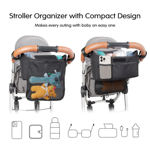

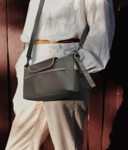

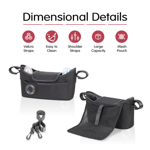

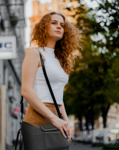

Direct use of automatic function calling (AFC) in Models.generate_content is not recommended. Instead, we recommend to use AFC in Chat.send_message. Similarly, direct use of AFC in Models.generate_content_stream is not recommended. Instead, we recommend to use AFC in Chat.send_message_stream.


Requesting premium render via Gemini image model (Attempt 1/10)...
Successfully saved to: output_models/modeled_Baby_Stroller_Organizer_2.jpg



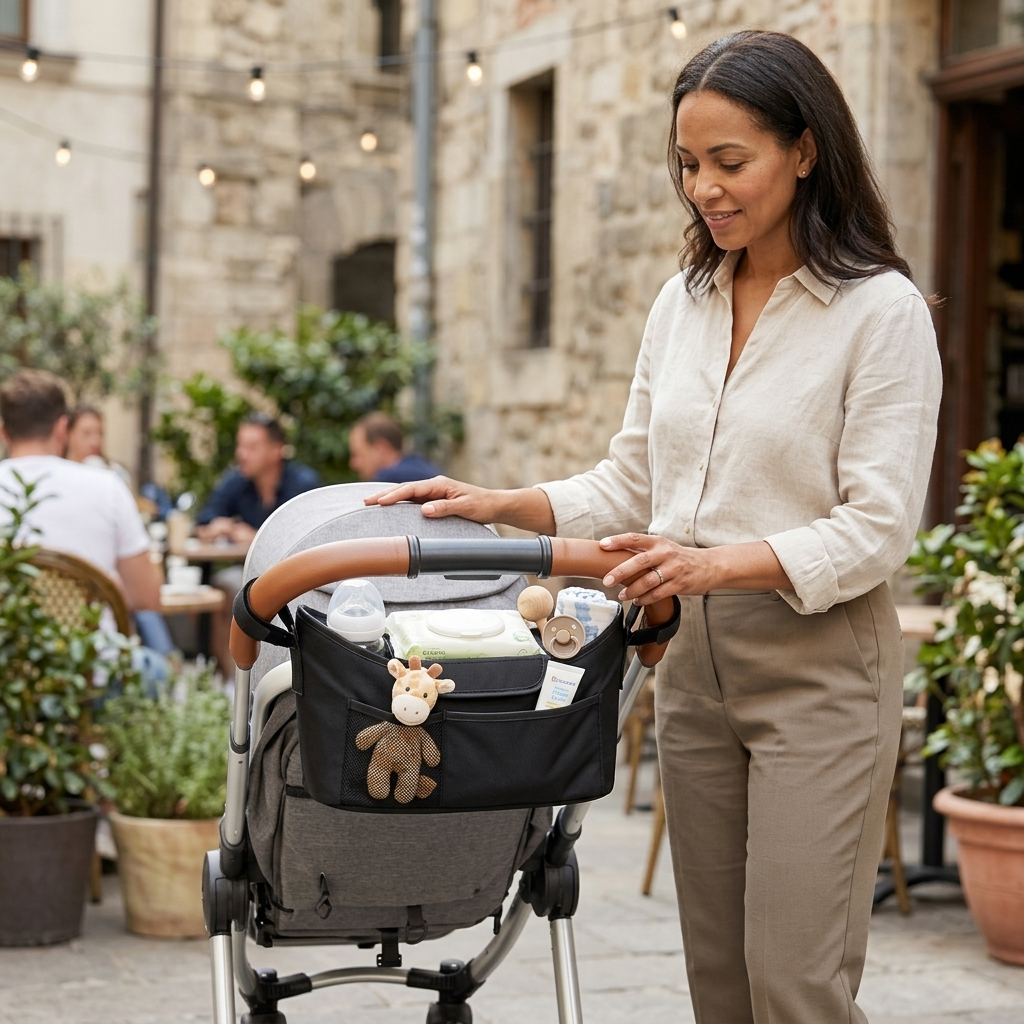

Cooling down for 8 seconds before the next product...



In [5]:
custom_prompts = {
    "Automatic Nail Clipper": (
        "Expert lifestyle product photographer, tasked with a photorealistic, natural lifestyle portrait of an adult using an ultra-compact electronic automatic nail care device." 
        "The device is extremely compact and small. Demonstrator can easily hold it using thumb and index finger." 
        "Refer carefully to the form factor in the reference images, specifically the integrated, non-protruding circular grooming slot on the top surface." 
        "The scene features a smiling male or female, aged 20 to 60 of random ethnicities, in a softly lit, warm residential setting, such as a cozy home vanity, a clean natural-light bathroom, or a comfortable bedroom seating area." 
        "The camera framing captures the person's face, upper body, and both hands in a natural, relaxed posture, with varied hairstyles and casual clothing styles suitable for the setting." 
        "The demonstrator is holding the tiny device delicately with the person's fingers, demonstrating its use by gently placing the person's opposite fingertip against the smooth styling surface. The device has a smooth, contoured, silver-grey and black body with NO protruding lever parts," 
        "featuring an integrated circular grooming area and clear window on the top face and also two circular grey button at at the center of the device." 
        "The background features a soft, diffused aesthetic with a shallow depth of field, keeping the focus on the person's interaction and natural smile. High-quality photorealistic lighting on the device, smooth skin, and perfectly manicured nails. NO Brand Logo or Brand Text." 
        "Strictly follow the product design from references."
    ),
    "Baby Nail File": (
        f"""
        You are an expert product photographer. Create a luxurious, soft-focus lifestyle commercial image of a gentle electric baby nail file being used by a smiling adult guardian on a child aged {chosen_age}'s tiny finger. Ensure the Baby nail file is being used on the child's own finger.
        Ensure there are no partial guardian or ghost in the frame. No hands coming out of nowhere.
        There should only be one guardian and one baby in the image. 
        The background should be a minimalist, modern nursery setting with clean lines, Scandinavian design, or warm pastel tones, featuring various plush textiles. 
        Soft, diffuse natural light, close-up details on the file's material, photorealistic, 8k. 
        The product body is entirely yellow with a perfectly smooth, seamless body and flush edges. 
        The top surface nail file is a circular flat disc, and the very top surface color is strictly {chosen_color}, and it is being used gently to trim the child's nail. 
        The device features only a simple duck graphic. 
        Crucially, the entire image surface is clean and completely free of any text, brand names, or logos.
        """
    ),
    "Baby Sculpting Device": (
        f""""A professional commercial product photograph in a luxury setting, rendered in ultra-realistic 8k resolution with shallow depth of field and soft ambient indoor lighting in gentle pastel tones. 
        The scene is a clean changing station countertop with varying marble patterns, and features a smiling woman, of random ethnicities and ages from young adult to mid-30s, well-seated. 
        She is holding the single, only baby facial sculpting device in the entire scene against her cheek, jawline, or under her eye to demonstrate its use.
        Ensure the product matches the form from the reference image.
        It has a single, dark, circular display face on top. 
        Crucially, embedded within this dark display screen, there is a distinct curved array of exactly 5 white, arc-shaped control buttons. 
        The device is held with the top display vertical to the bottom.
        On the countertop in the foreground, among the crystal-clear reflections, a curated collection of high-end baby accessories (such as a wooden brush, organic muslin cloths, a single boutique lotion bottle, and a different colored storage pouch) is arranged, 
        without any additional freestanding devices. There are absolutely no brand logos or text on the device, the woman, or any accessories. 
        There is no baby face image on the device. 
        There is only one single device in the whole frame, and it is in the woman's hand.
        **Carefully reference the images, and ensure there are absolutely only FIVE buttons on top of the circular display screen**"""
    ),
    "Baby Stroller Organizer": (
        "You are an expert product photographer"
        "Collect all reference images and analyze them carefully then you shoot generate a"
        "premium commercial placement shot of a sophisticated, durable black fabric baby stroller organizer attached by only two straps on each side "
        "to the leather-wrapped handle of an expensive urban stroller. The organizer is packed with organized "
        "baby essentials (bottles, wipes, small toys). Blurred background of a chic metropolitan cafe patio,"
        "bright daylight, commercial quality, sharp detail focus."
        "Create a unique image that generate a unique scenario fitting the product"
        "Generate new things that being put in the organizer, do not put the same thing always in the stroller organizer"
        "The demonstrator should be either a woman or man **of diverse ethnicities and across a broad age range (e.g., from young adult to mid-50s)"
        "**NO Brand Logo or Brand Text needed on the image**"
        "**Strictly follow the product design from references**"
        "**There are no pocket or pouch cup holder on both sides, strictly follow the designs from the reference images**"
        "The demonstrator should have only 2 hands."
    ),
    "Blue Stroller Cup Hodler": (
        "A photorealistic, medium-distance side-profile photograph of a random age (age 20 to 40) and Arabic Regions mom pushing a luxury stroller. Only 1 guardian should be in the frame. No other partial guardian should appear. Ensure the cup holder is in the frame." 
        "The mom is partially visible, walking and smiling, with her hands on the stroller handle. The stroller has a grey fabric canopy and a silver metal frame." 
        "Cup Holder center should securely attached to the stroller handle frame, parallel to the frame, is the black plastic double-section cup holder and snack tray unit." 
        "The camera angle captures the side profile of the unit, which is entirely smooth and unbranded on this visible surface, with zero text, zero logos, and zero protruding parts, knobs, or visible clamps;" 
        "the attachment clamp is completely hidden behind the unit. The cup holder holds a baby water bottle and the tray section is filled with the random snacks)." 
        "Bright daylight illuminates the scene."
        "Ensure there is only one stroller in the shot"
    ),
    "Breast Pumps": (
        "You are an expert product photographer"
        "A smiling woman, age 25 to 35 of diverse ethnicities, is seated on a comfortable bed in a peaceful,"
        "minimalist bedroom with soft morning window daylight. She is wearing a soft grey ribbed tank top with a modern, ergonomic, wireless breast pump discreetly" 
        "tucked inside the neckline of her top, demonstrating its wearable, hands-free design." 
        "She has one hand gently resting near the pump with a natural, peaceful expression. Warm neutral tones, photorealistic, 8k resolution, highly detailed."
        "**NO Brand Logo or Brand Text needed on the image**"
        "Create a unique image that generate a unique scenario fitting the product"
        "**Strictly follow the product design from references**"
        "**Ensure you have the breast pumps placed on top of the breasts with correct position and inside and covered by the tops**"
        "The breast pumps has a circular black screens on top displaying time with four white buttons featuring different features"
    ),
    "Breathable Baby Carrier(BBC)": (
        f"""Role & Style: You are an expert product photographer. 
        There should strictly only has one baby and a guardian in the frame.
        Generate a single, vibrant, dynamic high-end commercial lifestyle photograph. Do not generate multiple angles; it should only contain one shot.
        Subject & Scene: The image features exactly one guardian and one baby. The guardian is a smiling woman, aged 25-40, of diverse ethnicities, comfortably wearing an ergonomic baby carrier. 
        The setting should be a lifestyle scenario where the carrier is naturally needed, such as a sunny outdoor farmers market, a supermarket, at home, or a park. 
        She should have a casual hairstyle and clothing style suitable for the chosen setting. 
        The mom should do a natural, casual posture that fits the scenario to show the convenience of the product.
        **The Baby must face outward and look at directly at the camera and looks just fine, and make sure the baby is sitting in the baby carrier**
        Product Design (Strictly follow this): The baby carrier's main body is made of a smooth, solid black nylon/canvas material—do not make the entire carrier mesh, and a storiage zipper bag on the right side of the waist belt.
        The top head-support panel is folded down, showing a smooth light gray exterior, and revealing a small rounded breathable light gray mesh below the fold panel.
        The shoulder straps and thick waist belt are black. 
        **The fastening loop connecting the main panel to the shoulder straps must be white connecting black buckles.**
        Branding: The brand logo must be perfectly legible and clearly seen in white color and not in white square frames. It should just naturally paste on the product. 
        The logo consists of a anchor symbol positioned directly above the text "LUFFCABO".
        This logo must be accurately placed in two specific locations: small brand logo centered on the smooth white beneath the round breathable mesh panel size at (1.5cm x 1.5cm), and very tiny logo at the corner of the side storage zipper bag on the waist belt (0.5cm x 0.5cm) without in any frame, naturally paste on the product. 
        Carefully reference the reference images to make sure the product design is identical.
        Make sure the text LUFFCABO is spelled correctly. Ensure the scene is random and fitted for the product use"""
    ),
    "Breathable Baby CarrierM(BBM)": (
        "You are an expert product photographer. Collect all reference images and analyze them carefully." 
        "Generate a natural-light, heartwarming commercial lifestyle photograph featuring a smiling woman with a range of 25-40 ages, random ethnicities." 
        "The image features exactly one guardian and one baby."
        "**The Baby must face outward and look at directly at the camera**"
        "The guardian is a smiling woman, aged 25-40, of random ethnicities, comfortably wearing an ergonomic baby carrier."
        "The mom should do some casual posture that fits the scenario to show the convenience of the product."
        "The setting should be a lifestyle scenario where the carrier is naturally needed, such as an outdoor street, supermarket,at a lovely home setting, or a park." 
        "The camera framing captures her upper body and both hands in a natural, relaxed posture." 
        "She should have a hairstyle and clothing style suitable for the chosen setting."
        "The camera framing captures her upper body and her hands, which are positioned naturally and relaxed at her sides supporting the baby." 
        "The high-resolution details showcase the intricate mesh material of a specific light grey and white structured ergonomic, premium breathable baby carrier." 
        "The carrier is in an outward-facing configuration, and the baby, awake and looking at the camera, wears a light-colored onesie. Strictly follow the specific product design seen in the references." 
        "A single, distinct square brand logo patch is central to the lower part of the carrier, featuring a detailed anchor icon at the top and the text 'LUFFCABO' clearly and correctly displayed below the anchor within the same square border." 
        "This setting is a place where the Breathable Baby Carrier is needed. This is a single, direct shot."
        "**Ensure the brand logo text is legibly and correctly displayed as 'LUFFCABO'.**"
    ),
    "Detachable Cup Holder": (
        "A photorealistic, medium-distance side-profile photograph of a random age (age 20 to 40) and Arabic Regions mom pushing a luxury stroller with a baby sitting in the stroller. Only 1 guardian should be in the frame. No other partial guardian should appear. Ensure the cup holder is in the frame." 
        "The mom is partially visible, walking and smiling, with her hands on the stroller handle. The stroller has a grey fabric canopy and a silver metal frame." 
        "Cup Holder center should securely attached to the stroller handle frame, parallel to the frame, is the black plastic double-section cup holder and snack tray unit." 
        "The camera angle captures the side profile of the unit, which is entirely smooth and unbranded on this visible surface, with zero text, zero logos, and zero protruding parts, knobs, or visible clamps;" 
        "the attachment clamp is completely hidden behind the unit. The cup holder holds a baby water bottle and the tray section is filled with the random snacks)." 
        "Bright daylight illuminates the scene."
        "Ensure there is only one stroller in the shot"
    ),
    "Gray Baby Carrier": (
        f"""Role & Style: You are an expert product photographer. 
        There should strictly only has one baby and a guardian in the frame.
        Generate a single, vibrant, dynamic high-end commercial lifestyle photograph. Do not generate multiple angles; it should only contain one shot.
        Subject & Scene: The image features exactly one guardian and one baby. The guardian is a smiling woman, aged 25-40, of diverse ethnicity, comfortably wearing an ergonomic baby carrier. 
        The setting should be a lifestyle scenario where the carrier is naturally needed, such as a sunny outdoor farmers market, a supermarket, at home or a park. 
        She should have a casual hairstyle and clothing style suitable for the chosen setting. 
        The mom should do a natural, casual posture that fits the scenario to show the convenience of the product.
        **The Baby must face outward and look at directly at the camera and looks just fine, and make sure the baby is sitting in the baby carrier**
        Product Design (Strictly follow this): The baby carrier's main body is made of a smooth, solid light gray nylon/canvas material—do not make the entire carrier mesh, and a storiage zipper bag on the right side of the waist belt.
        The top head-support panel is folded down, showing a smooth light gray exterior, and revealing a small rounded breathable light gray mesh below the fold panel.
        The shoulder straps and thick waist belt are solid light gray. 
        The fastening loop connecting the main panel to the shoulder straps must be light gray connecting black buckles.
        Branding: The brand logo must be perfectly legible and clearly seen in light gray color and not in white square frames. It should just naturally paste on the product. 
        The logo consists of a anchor symbol positioned directly above the text "LUFFCABO".
        This logo must be accurately placed in two specific locations: small brand logo centered on the smooth light gray beneath the round breathable mesh panel size at (1.5cm x 1.5cm), and very tiny logo at the corner of the side storage zipper bag on the waist belt (0.5cm x 0.5cm) without in any frame, naturally paste on the product. 
        Carefully reference the reference images to make sure the product design is identical.
        Make sure the text LUFFCABO is spelled correctly."""
    ),
    "Gray stroller cup holder": (
        "A photorealistic, medium-distance side-profile photograph of a random-age (20 to 40) parent of any "
        "ethnicity pushing a luxury stroller with a baby sitting inside. Only one guardian should be in the frame"
        "no other partial guardian should appear. Ensure the cup holder is in the frame. The parent is "
        "visible, walking and smiling, with their hands on the stroller handle. The stroller has a "
        "grey fabric canopy and a silver metal frame. Centered on the stroller handle frame, parallel to the "
        "frame, is the black plastic double-section cup holder and snack tray unit. The camera angle captures "
        "the side profile of the unit, which is entirely smooth and unbranded on this visible surface, with "
        "zero text, zero logos, and zero protruding parts, knobs, or visible clamps; the attachment clamp is "
        "completely hidden behind the unit. The cup holder holds a baby water bottle and the tray section is "
        "filled with random snacks. Bright daylight illuminates the scene. Ensure there is only one stroller in "
        "the shot."
    ),
    "Gray Stroller Organizer": (
        "You are an expert product photographer"
        "Collect all reference images and analyze them carefully then you shoot generate a"
        "premium commercial placement shot of a sophisticated, durable fabric baby stroller organizer attached "
        "to the leather-wrapped handle of an expensive urban stroller. The organizer is packed with organized "
        "baby essentials (bottles, wipes, small toys). Blurred background of a chic metropolitan cafe patio,"
        "bright daylight, commercial quality, sharp detail focus."
        "Create a unique image that generate a unique scenario fitting the product"
        "Generate new things that being put in the organizer, do not put the same thing always in the stroller organizer"
        "The demonstrator should be a woman **of diverse ethnicities and across a broad age range (e.g., from young adult to mid-50s)"
        "**NO Brand Logo or Brand Text needed on the image**"
        "**Strictly follow the product design from references**"
        "There are no cup holder on sides, strictly follow the designs from the reference images"
    ),
    "Inflatable Baby Seat": (
        "You are an expert product photographer"
        "Collect all reference images and analyze them carefully then you shoot generate"
        "a warm, inviting commercial lifestyle shot of an inflatable baby seat resting safely on a soft living room rug. "
        "Natural ambient sunlight, cheerful modern home interior, crisp textures, sharp focus, 8k resolution. The primary logo on the inflatable seat must be rendered clearly and visible."
        "Nice to have baby playfully sitting on it and behaving some random happy faces or emotions and possibly holding some toys"
        "The logo LUFFCABO with an anchor on top is needed to be shown on the product in the black color"
        "**The Brand logo must be clearly seen, LUFFCABO and an anchor on top need to be clearly seen**"
        "Please create a high resolution image and make sure"
        "Create the image at place where the Breathable Baby Carrier is needed"
        "Create a unique image that generate a unique scenario fitting the product"
        "Strictly follow the product design from references"
        "Ensure the gurdian does not goes through the inflatable baby seat, has the guardian around the baby"
        "Double check the logo text LUFFCABO"
    ),
    "LED Beauty Mask": (
        "You are an expert product photographer"
        "Collect all reference images and analyze them carefully then you shoot generate a"
        "luxury cosmetic product commercial photograph featuring a sleek, multi-layered LED beauty mask. The mask is "
        "displayed on a polished marble vanity top in a high-end modern bathroom. Soft, diffuse light, close-up details "
        "on the LED arrays within the material, photorealistic, 8k."
        "The output image should purely just an LED mask put on the demonstrator face without any effect"
        "Have a women **of diverse ethnicities and across a broad age range (e.g., from young adult to mid-40s) holding it or putting on their face is the best"
        "**NO Brand Logo or Brand Text needed on the image**"
        "Create a unique image that generate a unique scenario fitting the product"
        "Strictly follow the product design from references"
        "There should only have one woman in the frame"
    )
}

# --- Randomized Selection and Folder Preparation ---
# Re-implementing the randomization to ensure correct execution.
# (Assumes your randomized logic in previous turns has prepared the selected_products list)or len(selected_products) != 4
if not selected_products:
    print("Error: Randomized selection failed or not confirmed in previous cells.")
else:
    for product_name in selected_products:
        product_dir = os.path.join(base_folder, product_name)
        images_in_folder = [f for f in os.listdir(product_dir) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]

        print(f"\n==========================================")
        print(f"Processing Product Folder: {product_name}")
        print(f"Found {len(images_in_folder)} image variant(s) as reference input.")
        print(f"==========================================")

        if not images_in_folder:
            print(f"No images found in {product_name}. Skipping...\n")
            continue

        base_clean_key = product_name.split('(')[0].strip()
        prompt_text = custom_prompts.get(
            base_clean_key,
            f"Professional commercial advertising photography of a parent using a {base_clean_key}. "
            f"Carefully analyze all reference images, and double check the output image to make sure it fits the prompt."
            f"Ensure the interaction between the demonstrator and the products fit logic and physic"
            f"If the product is a cup holder, do not show clamp in the image make sure its hidden and parallel to the side handle, and make sure there is only one stroller in the image."
            f"If the product is Baby Carrier or Inflatable seats, double check the brand logo LUFFCABO, and baby must face outward and look at the camera, and ensure the baby is sitting properly in the product."
            f"If the product is Automatic Nail Clipper, ensure the devide is middle finger long"
            f"If the product is Baby Sculpting Device, ensure there are only five white buttons on embedded within the black screen"
            f"Please generate the image carefully with details such as sizing and color matching."
            f"Ensure there is only one guardian in the image at a time, and all the body feature should stay normal and fits human logic"
            f"The scene of the frame should also be unique each time for both indoor or outdoor setting"
        )

        # Load ALL image variants for this product as reference input
        ref_images = []
        for image_file in images_in_folder:
            input_image_path = os.path.join(product_dir, image_file)
            try:
                img = Image.open(input_image_path)
                ref_images.append(img)
                preview = img.copy()
                preview.thumbnail((150, 150))
                display(preview)
            except Exception as e:
                print(f"Skipping unreadable image {image_file}: {e}")

        if not ref_images:
            print(f"No valid images could be loaded for {product_name}. Skipping...\n")
            continue

        contents = ref_images + [
            f"{prompt_text} Use the provided reference images to understand the exact product "
            f"(shape, color, logo, material) and generate ONE single best-quality, 8k resolution, and most polished "
            f"commercial lifestyle photograph of it. Do not generate multiple images — return only one."
            f"There will be no human check after you finished generating, so make sure u always generate the best quality that fits the description"
            f"Please generate the image carefully with details such as sizing and color matching."
        ]

        max_retries = 10
        for attempt in range(max_retries):
            try:
                print(f"Requesting premium render via Gemini image model (Attempt {attempt + 1}/{max_retries})...")

                response = client.models.generate_content(
                    model="gemini-3.1-flash-image",
                    contents=contents,
                    config=types.GenerateContentConfig(
                        response_modalities=["TEXT", "IMAGE"],
                        temperature=0.50, 
                        top_p=0.90,
                        safety_settings=[
                            types.SafetySetting(
                                category=types.HarmCategory.HARM_CATEGORY_DANGEROUS_CONTENT,
                                threshold=types.HarmBlockThreshold.BLOCK_ONLY_HIGH,
                            ),
                            types.SafetySetting(
                                category=types.HarmCategory.HARM_CATEGORY_HARASSMENT,
                                threshold=types.HarmBlockThreshold.BLOCK_ONLY_HIGH,
                            )
                        ]
                    )
                )

                if not response.candidates or not response.candidates[0].content or not response.candidates[0].content.parts:
                    # Print the finish reason (e.g., SAFETY, RECITAION, etc.) to help you debug
                    if response.candidates:
                        print(f"Blocked by API. Finish Reason: {response.candidates[0].finish_reason}")
                    raise RuntimeError("API returned an empty response. Likely blocked by safety filters.")
                
                image_bytes = None
                for part in response.candidates[0].content.parts:
                    if part.inline_data is not None:
                        image_bytes = part.inline_data.data
                        break

                if image_bytes is None:
                    raise RuntimeError("No image data returned in response")

                generated_image = Image.open(BytesIO(image_bytes))

                clean_prod_name = base_clean_key.replace(' ', '_')

                # Find existing files for this product to determine the next index
                existing_indices = []
                for f in os.listdir(output_folder):
                    if f.startswith(f"modeled_{clean_prod_name}_") and f.endswith(".jpg"):
                        try:
                            # Extract number from filename (assumes format modeled_Product_Name_X.jpg)
                            idx_str = f.split('_')[-1].split('.')[0]
                            existing_indices.append(int(idx_str))
                        except ValueError:
                            pass

                next_index = max(existing_indices) + 1 if existing_indices else 1
                output_filename = f"modeled_{clean_prod_name}_{next_index}.jpg"
                output_path = os.path.join(output_folder, output_filename)

                generated_image.convert("RGB").save(output_path, "JPEG")
                print(f"Successfully saved to: {output_path}\n")
                display(generated_image)
                break

            except Exception as e:
                wait_time = 3 * (attempt + 1)
                print(f"Encountered issue: {e}")
                if attempt < max_retries - 1:
                    print(f"Cooling down... waiting {wait_time} seconds before retrying...\n")
                    time.sleep(wait_time)
                else:
                    print(f"Failed to process {product_name} after multiple attempts.\n")

        print("Cooling down for 8 seconds before the next product...\n")
        time.sleep(8)
        